In [55]:
import CalculatedFieldSubroutines as cfs

#

import numpy as np

import pandas as pd

import random

#

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import KFold

from sklearn.metrics import confusion_matrix

#

from bayes_opt import BayesianOptimization

#

import matplotlib.pyplot as plt

import cartopy.crs as ccrs

from cartopy.io.img_tiles import GoogleTiles

from pandasgui import show

#

import warnings

In [56]:
## Hyperparameter Tuning Setup

moving_windows = [ 0, 2, 4 ] # sec

routes = [ 'Red', 'Green', 'Blue' ]

X_colnames = [ 'speedMps', 'brakePercentage', 'throttlePercentage', 'steeringPercentage', 'LatLonTotalStdDev' ]

y_colname = 'BinaryDisengagementExpanded'

metric_function = cfs.mf_balanced_accuracy

cv_num_of_splits = 10

In [57]:
gmID_list = cfs.list_whitelisted_gmIDs()

#

red_training_gmIDs = [ '61b12e7a-f234-11ee-bb33-fb353e7798cd', 'fcc6fcd2-f013-11ee-b966-fb353e7798cd', '05c7c824-cab8-11ee-aa4d-1d66adf2f0c7', '211bdb36-f0da-11ee-ba1b-fb353e7798cd', '868de15e-f3b3-11ee-bb4e-fb353e7798cd', '72a03d4a-efe9-11ee-b966-fb353e7798cd', '7fb7b9c0-c881-11ee-a7fc-dd032dba19e8', '96f7a614-f549-11ee-8afa-cb629b0d53e6', '1bbbfbae-c839-11ee-a7fc-dd032dba19e8', '622bd2e8-f0e4-11ee-ba1f-fb353e7798cd', '9798fe24-f143-11ee-ba78-fb353e7798cd', '88dd6fbe-f224-11ee-bb21-fb353e7798cd', 'c9c6856c-d33c-11ee-b437-336917683bb8', 'd12cd1c4-caec-11ee-909c-e1dc60cf66f9', '817d6848-efb6-11ee-b966-fb353e7798cd', '1b6aca0e-efdf-11ee-b966-fb353e7798cd', '41b67a28-f52f-11ee-8afa-cb629b0d53e6', 'fc211bb2-efca-11ee-b966-fb353e7798cd', '84d96f18-f214-11ee-bb13-fb353e7798cd', 'fe973c9c-f53c-11ee-8afa-cb629b0d53e6', '3151e9e2-eff3-11ee-b966-fb353e7798cd', 'c0555ef0-f50f-11ee-8afa-cb629b0d53e6', 'f711e68e-f0e1-11ee-ba1f-fb353e7798cd', 'c338788a-d324-11ee-b437-336917683bb8', 'd21965e6-f0fa-11ee-ba37-fb353e7798cd', '88a68dd8-eef9-11ee-9385-ef789ffde1d3', 'f41cbd44-eff8-11ee-b966-fb353e7798cd', '43a1a35e-f362-11ee-bb4e-fb353e7798cd', '6d2ea45a-c839-11ee-a7fc-dd032dba19e8', '01e65360-efd4-11ee-b966-fb353e7798cd', '7cbd932e-f244-11ee-bb3f-fb353e7798cd', '65cfbfd6-f396-11ee-bb4e-fb353e7798cd', '94c53148-eeed-11ee-9385-ef789ffde1d3', 'fd1ab258-efa7-11ee-b966-fb353e7798cd', 'e7b934a8-ef1a-11ee-9385-ef789ffde1d3', 'de933de8-f112-11ee-ba4d-fb353e7798cd', 'd3698592-ef9d-11ee-b966-fb353e7798cd', 'dd72fdec-f0cf-11ee-ba0d-fb353e7798cd', 'b82476fe-f1f3-11ee-baff-fb353e7798cd', 'f755cf60-f132-11ee-ba6d-fb353e7798cd', '853ef120-cad3-11ee-909c-e1dc60cf66f9', 'f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd', 'cf831f42-f353-11ee-bb4e-fb353e7798cd', 'ecebb942-f162-11ee-ba97-fb353e7798cd', '219f7eb8-ef87-11ee-b966-fb353e7798cd', 'd24820c8-f197-11ee-babe-fb353e7798cd', '3d2d29ec-ef95-11ee-b966-fb353e7798cd', '457dc5ee-f02a-11ee-b966-fb353e7798cd', '2462c9d0-eecd-11ee-9385-ef789ffde1d3', '51ef6da6-ca9f-11ee-909c-e1dc60cf66f9', 'c25271be-f3a4-11ee-bb4e-fb353e7798cd', '8347b862-efad-11ee-b966-fb353e7798cd', '8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd', '9189a2a8-f121-11ee-ba5b-fb353e7798cd', '8fa6fe80-c869-11ee-a7fc-dd032dba19e8' ]

green_training_gmIDs = [ '3ec95686-f053-11ee-b988-fb353e7798cd', 'b31aca98-cb95-11ee-909c-e1dc60cf66f9', '25e27b86-f06a-11ee-b9a3-fb353e7798cd', 'bf9157f0-f16b-11ee-ba9e-fb353e7798cd', '51b74168-f19d-11ee-babf-fb353e7798cd', 'de493be2-f10f-11ee-ba4b-fb353e7798cd', 'ece2a8be-f047-11ee-b97d-fb353e7798cd', '044d976e-f0e5-11ee-ba20-fb353e7798cd', '98692fde-f1a4-11ee-bac6-fb353e7798cd', '5afabc8c-f035-11ee-b966-fb353e7798cd', '072ef896-cbac-11ee-909c-e1dc60cf66f9', 'c59a54e0-f179-11ee-baab-fb353e7798cd', 'bbbd0cc6-f0dc-11ee-ba1e-fb353e7798cd', 'ba87f3ec-f07e-11ee-b9b4-fb353e7798cd', '96ceec56-f1cf-11ee-bae4-fb353e7798cd', '40706f50-f03b-11ee-b96e-fb353e7798cd', 'f570c51c-f15d-11ee-ba91-fb353e7798cd', 'f12112ba-f1c0-11ee-bada-fb353e7798cd', '961fd9cc-f103-11ee-ba3f-fb353e7798cd', '5f7ce340-f1c8-11ee-bae0-fb353e7798cd', 'cf7148d8-f058-11ee-b98a-fb353e7798cd', '848e44a6-f134-11ee-ba6d-fb353e7798cd', '3a7dc9a6-f042-11ee-b974-fb353e7798cd', 'c9be2042-f0de-11ee-ba1e-fb353e7798cd', '9736e77c-f187-11ee-bab6-fb353e7798cd', '5fc763f6-f1ab-11ee-bacd-fb353e7798cd', '4c88757c-f157-11ee-ba89-fb353e7798cd', 'a231c0b0-f142-11ee-ba76-fb353e7798cd', '53fad09e-f0f7-11ee-ba2f-fb353e7798cd', '5c7a9ab2-f13b-11ee-ba72-fb353e7798cd', '4cf81634-f238-11ee-bb34-fb353e7798cd', 'a08a8c7e-f1fb-11ee-bb05-fb353e7798cd', '3ed4aa16-f1d6-11ee-bae6-fb353e7798cd', '25135418-f250-11ee-bb4a-fb353e7798cd', 'c1b320e2-f079-11ee-b9b0-fb353e7798cd', '43abeb00-f206-11ee-bb07-fb353e7798cd', 'fe0395f0-f1ea-11ee-baf9-fb353e7798cd', '3d8020aa-cb7f-11ee-909c-e1dc60cf66f9', '14b6bc9c-f064-11ee-b998-fb353e7798cd', '870cfd32-f1b9-11ee-bad5-fb353e7798cd', 'c2f54552-f06f-11ee-b9a9-fb353e7798cd', 'dea29156-f123-11ee-ba5d-fb353e7798cd', '3c415ade-d353-11ee-b437-336917683bb8', 'a901fe40-f0fd-11ee-ba39-fb353e7798cd', 'c4146d46-f074-11ee-b9ac-fb353e7798cd', 'de226278-f25a-11ee-bb4e-fb353e7798cd', 'd7cb9c92-f164-11ee-ba97-fb353e7798cd', '88b0613a-d35d-11ee-b437-336917683bb8', 'c4fca7bc-f18e-11ee-bab8-fb353e7798cd', 'ed352100-cba0-11ee-909c-e1dc60cf66f9', 'cbdc93f4-f255-11ee-bb4e-fb353e7798cd', '8e5c4fc2-f149-11ee-ba7f-fb353e7798cd', 'bb4d37d4-f109-11ee-ba46-fb353e7798cd', '236836f6-f1dd-11ee-bae8-fb353e7798cd', '7948628e-f20b-11ee-bb0f-fb353e7798cd', 'c14299be-f180-11ee-bab0-fb353e7798cd', '73bc30cc-f150-11ee-ba84-fb353e7798cd', '7e3d64da-f12d-11ee-ba68-fb353e7798cd', '837fc882-cb5a-11ee-909c-e1dc60cf66f9', 'f8fd0fd8-f243-11ee-bb3f-fb353e7798cd', '58d78342-f24a-11ee-bb45-fb353e7798cd', '8adb6498-f04d-11ee-b981-fb353e7798cd', '271fee10-cb8b-11ee-909c-e1dc60cf66f9', '99b9f446-f1b2-11ee-bad3-fb353e7798cd' ]

blue_training_gmIDs = [ '7228e03a-ebf0-11ee-b297-3b0ad9d5d6c6', '8c57e8ac-dbec-11ee-a158-97f8443fd730', '17876fec-ea66-11ee-b297-3b0ad9d5d6c6', 'd1d090d4-ea7c-11ee-b297-3b0ad9d5d6c6', 'ed7f2038-ea1e-11ee-b297-3b0ad9d5d6c6', '6af236d6-d98f-11ee-a158-97f8443fd730', '64737d98-d312-11ee-b437-336917683bb8', '5240e750-ec30-11ee-b297-3b0ad9d5d6c6', '7613801a-edcb-11ee-9385-ef789ffde1d3', '68c289fa-dbd4-11ee-a158-97f8443fd730', '76683d3c-db18-11ee-a158-97f8443fd730', '69ab88ec-dc17-11ee-a158-97f8443fd730', '7f09f6c6-a5b0-11ee-88ec-eb6a8d5269b4', '3d2a80f0-ec81-11ee-b297-3b0ad9d5d6c6', 'feaf2ba8-d28d-11ee-b437-336917683bb8', 'e2079a78-dc1d-11ee-a158-97f8443fd730', 'b224ef9c-ec10-11ee-b297-3b0ad9d5d6c6', 'ba28b352-ec8f-11ee-b297-3b0ad9d5d6c6', '59c189d8-ed54-11ee-9385-ef789ffde1d3', '2d35c522-eba2-11ee-b297-3b0ad9d5d6c6', '3343fd3c-eb87-11ee-b297-3b0ad9d5d6c6', 'c0624e24-d9aa-11ee-a158-97f8443fd730', 'a253145a-d2a6-11ee-b437-336917683bb8', '9830d896-d2dc-11ee-b437-336917683bb8', 'aa86a660-dc05-11ee-a158-97f8443fd730', '90101c36-a621-11ee-88ec-eb6a8d5269b4', '82d39c74-ea59-11ee-b297-3b0ad9d5d6c6', 'f9d62032-db2a-11ee-a158-97f8443fd730', 'af10e22a-ebb1-11ee-b297-3b0ad9d5d6c6', '47561998-d9c3-11ee-a158-97f8443fd730', '64875cc0-d054-11ee-9435-f7e542e2436c', 'df8e3742-ec54-11ee-b297-3b0ad9d5d6c6', '3a2a78cc-db21-11ee-a158-97f8443fd730', '721a9830-ece6-11ee-b297-3b0ad9d5d6c6', '2bc6ebb8-a529-11ee-88ec-eb6a8d5269b4', '4d0254fc-ec73-11ee-b297-3b0ad9d5d6c6', 'dc39aa14-db32-11ee-a158-97f8443fd730', '25d3bdc8-ecbc-11ee-b297-3b0ad9d5d6c6', '8b6a6cfc-ed6d-11ee-9385-ef789ffde1d3', 'e6d7d384-db40-11ee-a158-97f8443fd730', 'a17c1280-ea10-11ee-b297-3b0ad9d5d6c6', '36663b02-ea87-11ee-b297-3b0ad9d5d6c6', '71a18322-ecab-11ee-b297-3b0ad9d5d6c6', 'cf6fdf3a-eaa3-11ee-b297-3b0ad9d5d6c6', '57d240d6-ea4d-11ee-b297-3b0ad9d5d6c6', 'baf0e4be-bede-11ee-835b-599066b5eb60', '530de03a-ed79-11ee-9385-ef789ffde1d3', '43914d48-ed85-11ee-9385-ef789ffde1d3', 'a7c98b32-ebc2-11ee-b297-3b0ad9d5d6c6', 'fc119dfc-eb67-11ee-b297-3b0ad9d5d6c6', 'c7c02bda-ebe0-11ee-b297-3b0ad9d5d6c6', '39ba7438-d0d5-11ee-9435-f7e542e2436c', 'e8a8b2be-edbf-11ee-9385-ef789ffde1d3', '3ea96640-ea37-11ee-b297-3b0ad9d5d6c6', '21376e38-ec01-11ee-b297-3b0ad9d5d6c6', '513a670c-eea9-11ee-9385-ef789ffde1d3', '06cbdbc0-db4d-11ee-a158-97f8443fd730', '559495ca-d270-11ee-b437-336917683bb8', '04151804-ec20-11ee-b297-3b0ad9d5d6c6', 'd62ee6e8-ed02-11ee-9385-ef789ffde1d3', '154fab12-a43f-11ee-88ec-eb6a8d5269b4', '58263e34-a45c-11ee-88ec-eb6a8d5269b4', 'acd71bc0-ecf4-11ee-9385-ef789ffde1d3', '3441fc36-ecca-11ee-b297-3b0ad9d5d6c6', 'f671c05c-a5e4-11ee-88ec-eb6a8d5269b4', 'c8f54ac0-ebd2-11ee-b297-3b0ad9d5d6c6', '326699c2-ecd8-11ee-b297-3b0ad9d5d6c6', '3ce8a358-edd8-11ee-9385-ef789ffde1d3', '286c70cc-d2f7-11ee-b437-336917683bb8', '20cbfe8c-ea2b-11ee-b297-3b0ad9d5d6c6', 'c9023e32-ed90-11ee-9385-ef789ffde1d3', 'f0bcec4e-ed3e-11ee-9385-ef789ffde1d3', 'd94ef300-ed60-11ee-9385-ef789ffde1d3', 'e269948a-ed9d-11ee-9385-ef789ffde1d3', 'f6ac3c82-a445-11ee-88ec-eb6a8d5269b4', '80340ab8-d054-11ee-9435-f7e542e2436c', 'b76f33be-ea61-11ee-b297-3b0ad9d5d6c6' ]

#

red_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Red' ) and ( gmID not in red_training_gmIDs ) ) ]

green_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Green' ) and ( gmID not in green_training_gmIDs ) ) ]

blue_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Blue' ) and ( gmID not in blue_training_gmIDs ) ) ]

In [18]:
hyperparameter_tuning_results = {}

for route in routes:

    #

    if ( route == 'Red' ):

        training_gmIDs, testing_gmIDs = red_training_gmIDs, red_testing_gmIDs

    elif ( route == 'Green' ):

        training_gmIDs, testing_gmIDs = green_training_gmIDs, green_testing_gmIDs

    elif ( route == 'Blue' ):

        training_gmIDs, testing_gmIDs = blue_training_gmIDs, blue_testing_gmIDs

    #

    for moving_window in moving_windows:

        #

        training_dfs, testing_dfs = [], []

        for training_gmID in training_gmIDs:

            training_df = cfs.retrieve_gmID_preprocessed_moving_data_v3_reduced( gmID = training_gmID, 
                                                                                 moving_window = moving_window )

            training_dfs.append( training_df )

        for testing_gmID in testing_gmIDs:

            testing_df = cfs.retrieve_gmID_preprocessed_moving_data_v3_reduced( gmID = testing_gmID, 
                                                                                moving_window = moving_window )

            testing_dfs.append( testing_df )

        #

        if ( moving_window > 0 ):

            string = '_mean'

        else:

            string = ''

        modified_X_colnames = [ X_colname + string for X_colname in X_colnames ]

        #

        def function_to_maximize( max_depth, min_samples_split, min_samples_leaf ):

            value = cfs.BinaryClassification_DecisionTree_CV( train_dfs = training_dfs, \
                                                              X_colnames = modified_X_colnames, \
                                                              y_colname = y_colname, \
                                                              metric_function = metric_function, \
                                                              dt_random_state = 0, \
                                                              cv_num_of_splits = cv_num_of_splits, \
                                                              cv_shuffle = False, \
                                                              cv_random_state = None, \
                                                              y_labels = [ 0, 1 ], \
                                                              criterion = 'entropy', \
                                                              max_depth = round( max_depth ), \
                                                              min_samples_split = round( min_samples_split ), \
                                                              min_samples_leaf = round( min_samples_leaf ) )

            return value

        #

        parameter_bounds = { 
            
            'max_depth': ( 1, 100 ),
            
            'min_samples_split': ( 2, 500 ),
            
            'min_samples_leaf': ( 1, 500 )
        
        }

        #

        optimizer = BayesianOptimization( f = function_to_maximize, \
                                          pbounds = parameter_bounds, \
                                          random_state = 0, \
                                          verbose = 1 )

        optimizer.maximize( n_iter = 100, init_points = 100 )

        #

        best_params_bayes = optimizer.max[ 'params' ]

        best_params_bayes[ 'max_depth' ] = round( best_params_bayes[ 'max_depth' ] )

        best_params_bayes[ 'min_samples_split' ] = round( best_params_bayes[ 'min_samples_split' ] )

        best_params_bayes[ 'min_samples_leaf' ] = round( best_params_bayes[ 'min_samples_leaf' ] )

        best_score_bayes = optimizer.max[ 'target' ]

        #

        hyperparameter_tuning_results[ f'{ route }_{ moving_window }' ] = { 'tuned_hyperparameters' : best_params_bayes, metric_function : best_score_bayes }

        print( hyperparameter_tuning_results )

|   iter    |  target   | max_depth | min_sa... | min_sa... |
-------------------------------------------------------------
| 6         | 0.5291    | 9.626     | 11.09     | 416.6     |
| 12        | 0.5321    | 57.27     | 10.38     | 309.6     |
| 56        | 0.5376    | 85.72     | 6.845     | 181.3     |
| 101       | 0.5472    | 94.79     | 2.034     | 106.0     |
| 102       | 0.5482    | 45.76     | 5.388     | 82.86     |
| 103       | 0.5614    | 69.67     | 5.093     | 27.75     |
| 104       | 0.572     | 96.55     | 3.362     | 10.52     |
| 107       | 0.5736    | 48.95     | 3.19      | 8.244     |
| 109       | 0.5742    | 86.7      | 2.867     | 2.049     |
| 178       | 0.5777    | 91.06     | 1.05      | 2.426     |
{'Red_0': {'tuned_hyperparameters': {'max_depth': 31, 'min_samples_leaf': 1, 'min_samples_split': 4}, <function mf_balanced_accuracy at 0x73e51059f520>: np.float64(0.551058711036643)}, 'Red_2': {'tuned_hyperparameters': {'max_depth': 76, 'min_samples_leaf'

Red Route - 0 [sec] Moving Window

Disengagement Precision: 0.117

Disengagement Recall: 0.127

Unique Disengagement Recall: 0.380

Disengagement F1-Score: 0.122

Disengagement Accuracy: 0.985

Disengagement Balanced Accuracy: 0.560

                    Importance
LatLonTotalStdDev     0.376527
speedMps              0.271631
steeringPercentage    0.176944
brakePercentage       0.102994
throttlePercentage    0.071905


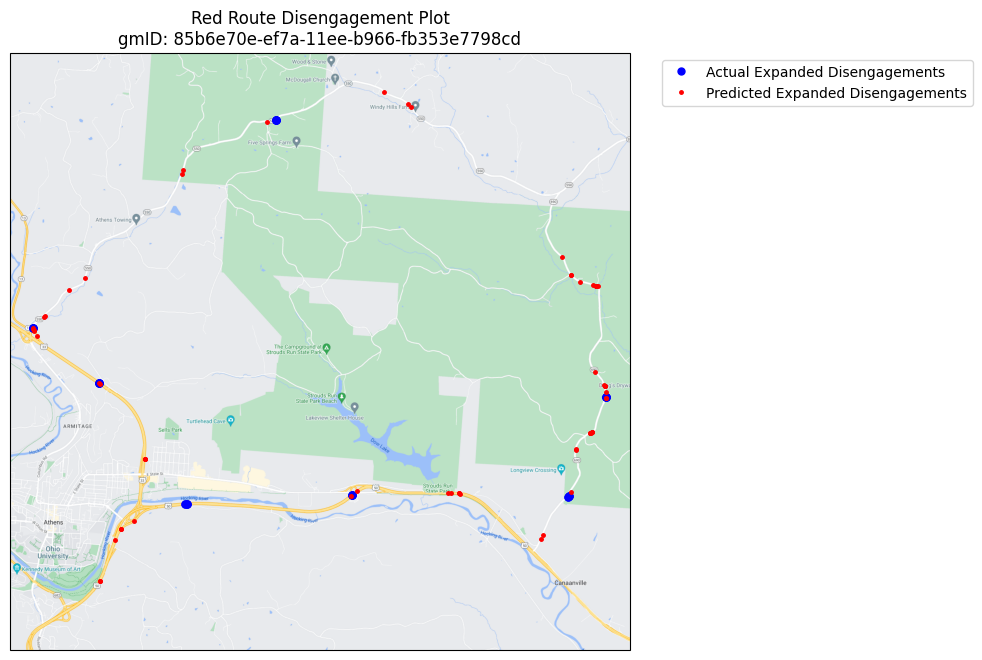

Red Route - 2 [sec] Moving Window

Disengagement Precision: 0.124

Disengagement Recall: 0.092

Unique Disengagement Recall: 0.247

Disengagement F1-Score: 0.106

Disengagement Accuracy: 0.988

Disengagement Balanced Accuracy: 0.542

                    Importance
LatLonTotalStdDev     0.270056
speedMps              0.244160
steeringPercentage    0.197760
throttlePercentage    0.149729
brakePercentage       0.138294


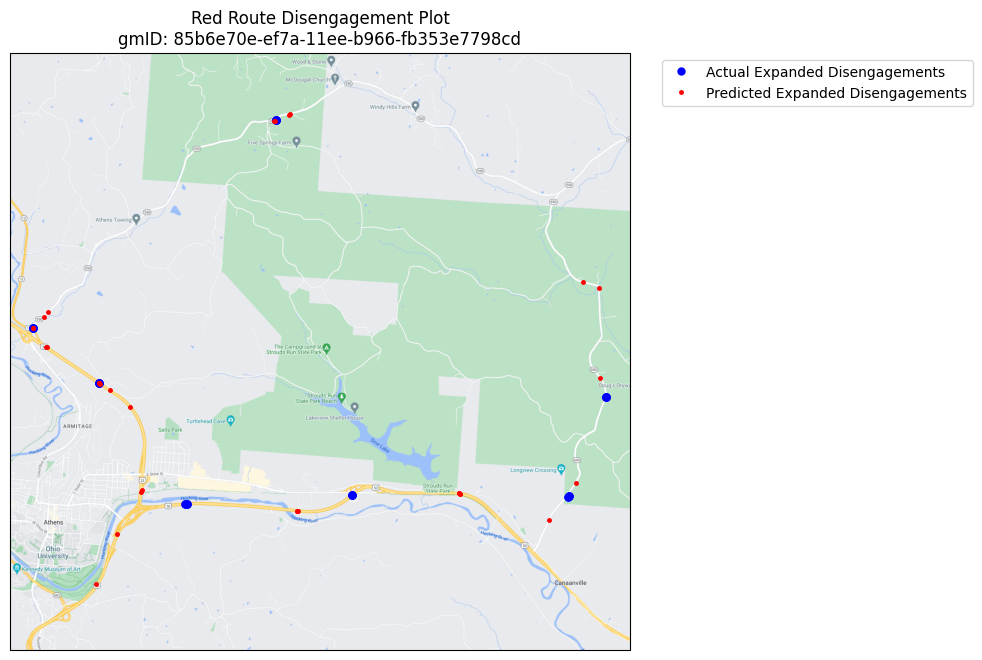

Red Route - 4 [sec] Moving Window

Disengagement Precision: 0.019

Disengagement Recall: 0.003

Unique Disengagement Recall: 0.013

Disengagement F1-Score: 0.005

Disengagement Accuracy: 0.991

Disengagement Balanced Accuracy: 0.497

                    Importance
LatLonTotalStdDev     0.246811
speedMps              0.235289
steeringPercentage    0.199370
brakePercentage       0.161590
throttlePercentage    0.156940


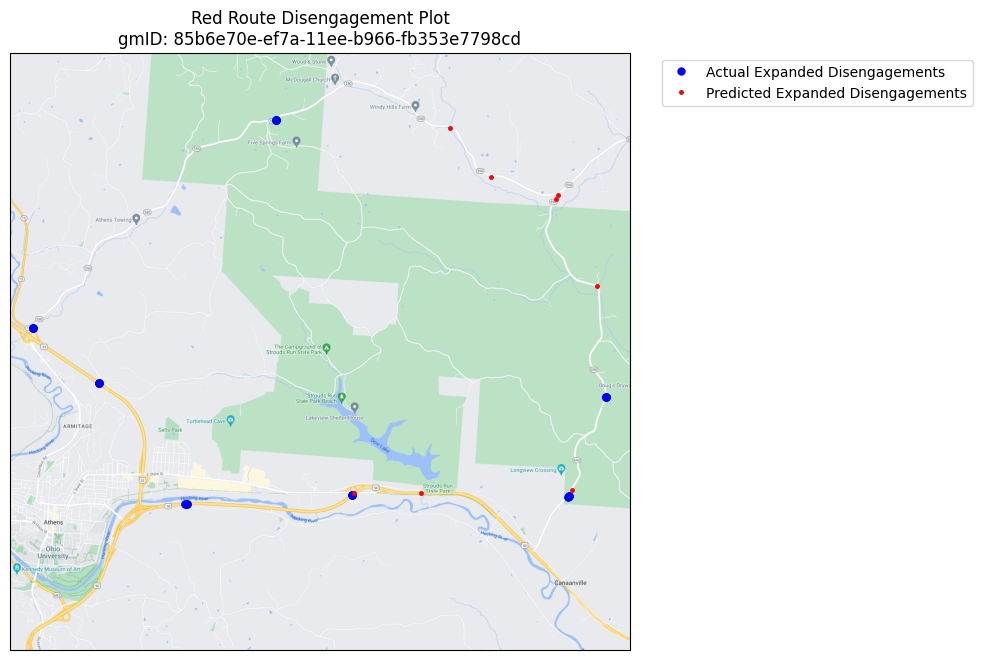

Green Route - 0 [sec] Moving Window

Disengagement Precision: 0.139

Disengagement Recall: 0.110

Unique Disengagement Recall: 0.220

Disengagement F1-Score: 0.122

Disengagement Accuracy: 0.987

Disengagement Balanced Accuracy: 0.551

                    Importance
LatLonTotalStdDev     0.344989
steeringPercentage    0.258254
speedMps              0.203626
brakePercentage       0.132523
throttlePercentage    0.060608


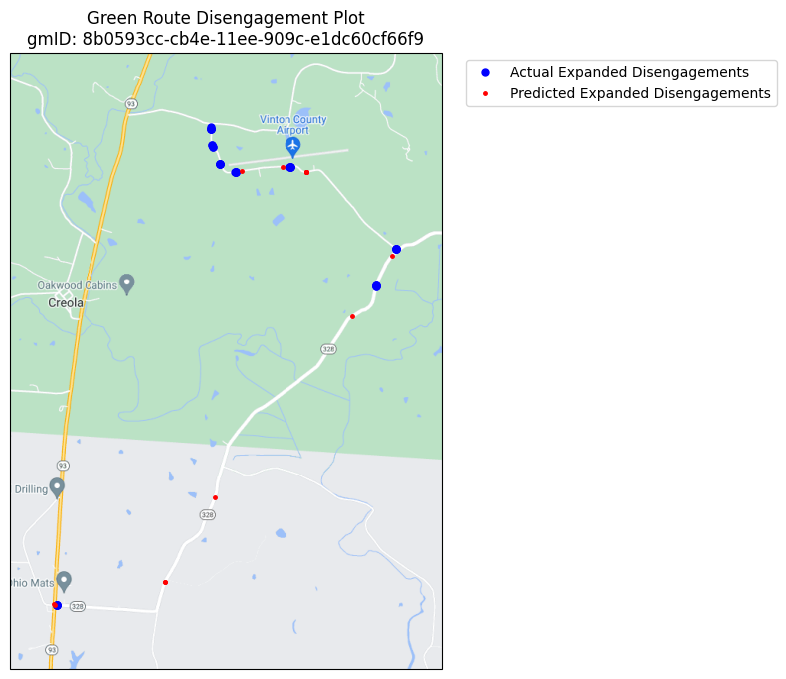

Green Route - 2 [sec] Moving Window

Disengagement Precision: 0.134

Disengagement Recall: 0.093

Unique Disengagement Recall: 0.154

Disengagement F1-Score: 0.110

Disengagement Accuracy: 0.987

Disengagement Balanced Accuracy: 0.543

                    Importance
LatLonTotalStdDev     0.282925
speedMps              0.223579
brakePercentage       0.199201
steeringPercentage    0.187264
throttlePercentage    0.107031


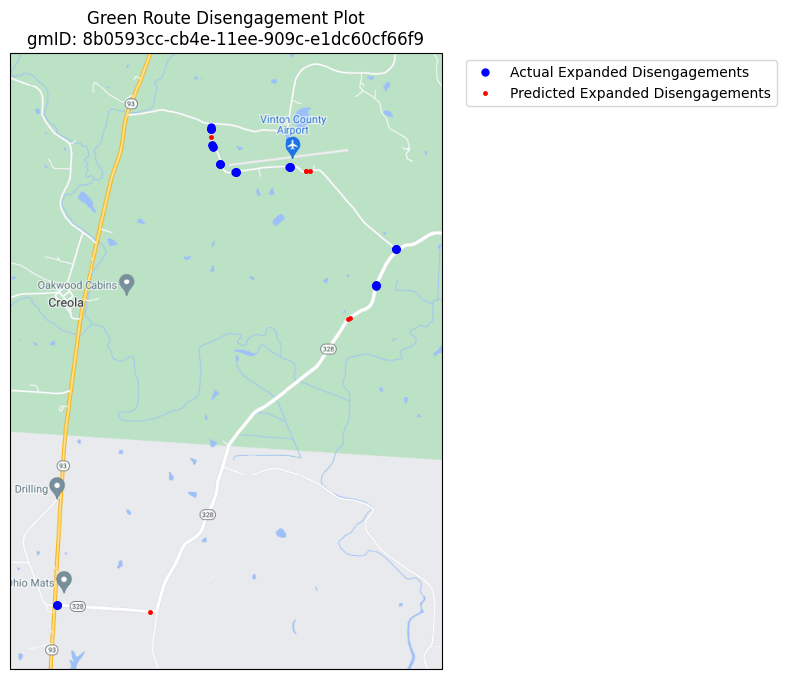

Green Route - 4 [sec] Moving Window

Disengagement Precision: 0.098

Disengagement Recall: 0.051

Unique Disengagement Recall: 0.088

Disengagement F1-Score: 0.067

Disengagement Accuracy: 0.988

Disengagement Balanced Accuracy: 0.522

                    Importance
LatLonTotalStdDev     0.305561
speedMps              0.267452
brakePercentage       0.179334
steeringPercentage    0.160871
throttlePercentage    0.086782


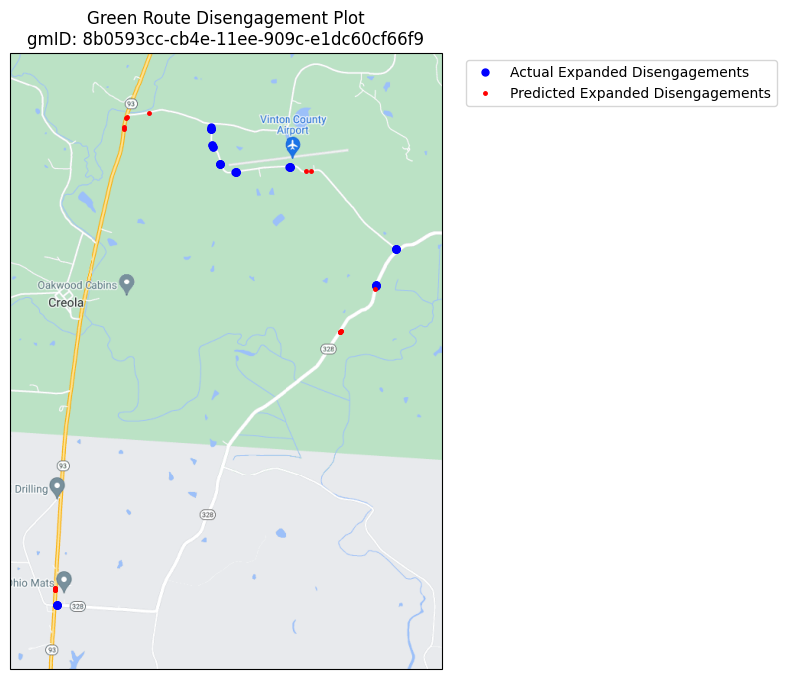

Blue Route - 0 [sec] Moving Window

Disengagement Precision: 0.102

Disengagement Recall: 0.132

Unique Disengagement Recall: 0.360

Disengagement F1-Score: 0.115

Disengagement Accuracy: 0.983

Disengagement Balanced Accuracy: 0.563

                    Importance
LatLonTotalStdDev     0.333575
speedMps              0.231632
steeringPercentage    0.218493
brakePercentage       0.132862
throttlePercentage    0.083438


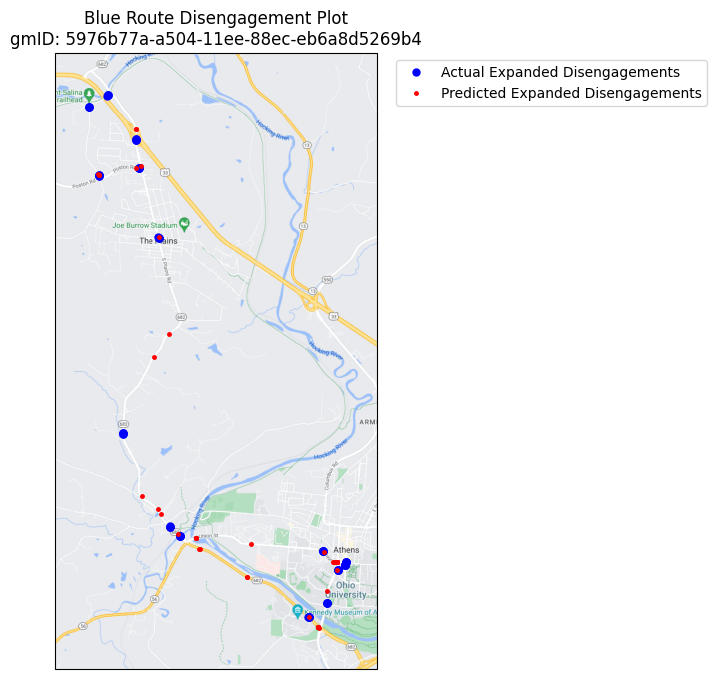

Blue Route - 2 [sec] Moving Window

Disengagement Precision: 0.101

Disengagement Recall: 0.093

Unique Disengagement Recall: 0.246

Disengagement F1-Score: 0.097

Disengagement Accuracy: 0.986

Disengagement Balanced Accuracy: 0.543

                    Importance
LatLonTotalStdDev     0.244226
speedMps              0.216747
steeringPercentage    0.196939
throttlePercentage    0.174315
brakePercentage       0.167774


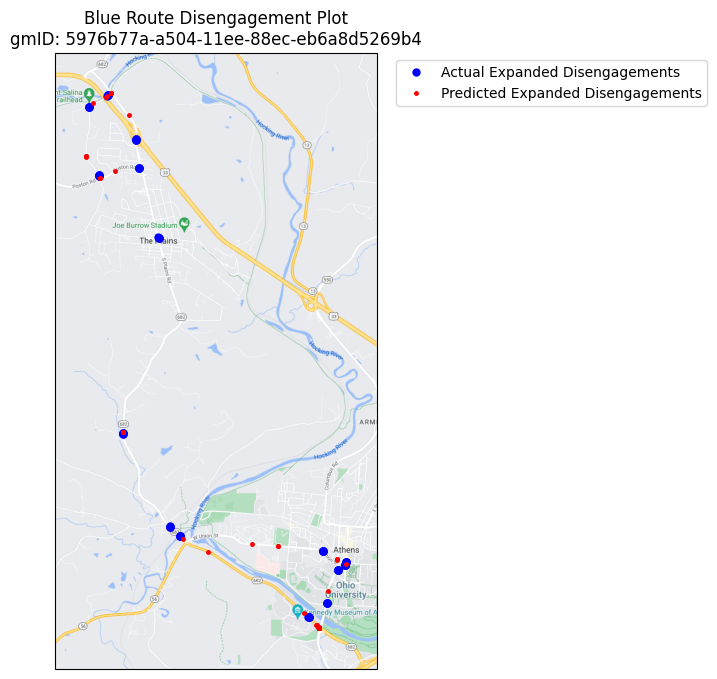

Blue Route - 4 [sec] Moving Window

Disengagement Precision: 0.087

Disengagement Recall: 0.075

Unique Disengagement Recall: 0.182

Disengagement F1-Score: 0.081

Disengagement Accuracy: 0.986

Disengagement Balanced Accuracy: 0.534

                    Importance
LatLonTotalStdDev     0.273887
speedMps              0.218149
steeringPercentage    0.206798
brakePercentage       0.152914
throttlePercentage    0.148252


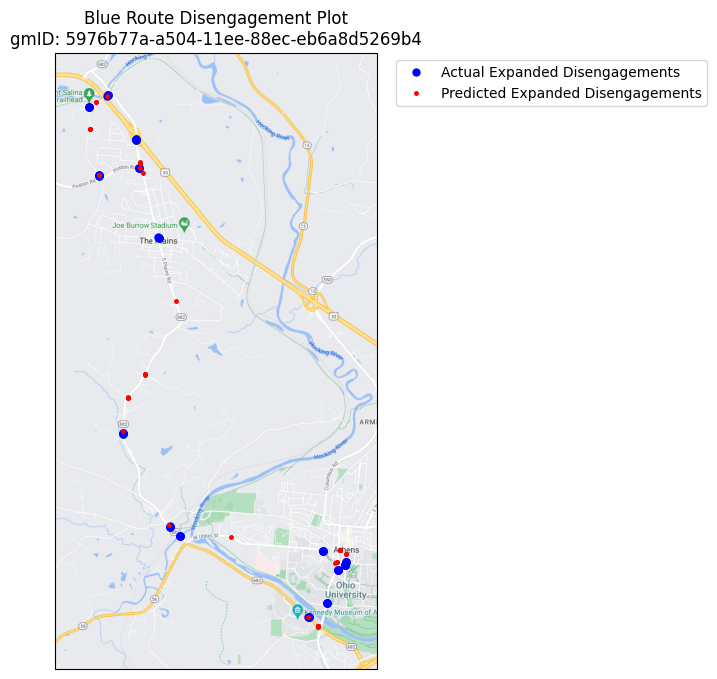

In [59]:
for route in routes:

    #

    if ( route == 'Red' ):

        training_gmIDs, testing_gmIDs = red_training_gmIDs, red_testing_gmIDs

    elif ( route == 'Green' ):

        training_gmIDs, testing_gmIDs = green_training_gmIDs, green_testing_gmIDs

    elif ( route == 'Blue' ):

        training_gmIDs, testing_gmIDs = blue_training_gmIDs, blue_testing_gmIDs

    #

    for moving_window in moving_windows:

        #

        training_dfs, testing_dfs = [], []

        for training_gmID in training_gmIDs:

            training_df = cfs.retrieve_gmID_preprocessed_moving_data_v3_reduced( gmID = training_gmID, 
                                                                                 moving_window = moving_window )

            training_dfs.append( training_df )

        for testing_gmID in testing_gmIDs:

            testing_df = cfs.retrieve_gmID_preprocessed_moving_data_v3_reduced( gmID = testing_gmID, 
                                                                                moving_window = moving_window )

            testing_dfs.append( testing_df )

        #

        if ( moving_window > 0 ):

            string = '_mean'

        else:

            string = ''

        modified_X_colnames = [ X_colname + string for X_colname in X_colnames ]

        #

        cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = training_dfs, \
                                                                                       test_dfs = testing_dfs, \
                                                                                       X_colnames = modified_X_colnames, \
                                                                                       y_colname = y_colname, \
                                                                                       dt_random_state = 0, \
                                                                                       y_labels = [ 0, 1 ], \
                                                                                       **hyperparameter_tuning_results[ f'{ route }_{ moving_window }' ][ 'tuned_hyperparameters' ] )

        #

        testing_df = pd.concat( testing_dfs )

        testing_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

        #

        tn, fp, fn, tp = cm_values.values()

        metrics = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = False )

        unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                        y_pred = y_pred_test, \
                                                                        true_DisengagementExpandedID_col = testing_df[ 'DisengagementExpandedID' ] )

        udr = unique_disengagement_recall_[ 'unique_disengagement_recall' ]

        #

        print( f'{ route } Route - { moving_window } [sec] Moving Window\n' )

        print( f'Disengagement Precision: { metrics[ 4 ]:.3f}\n' )

        print( f'Disengagement Recall: { metrics[ 5 ]:.3f}\n' )

        print( f'Unique Disengagement Recall: { udr:.3f}\n' )

        print( f'Disengagement F1-Score: { metrics[ 7 ]:.3f}\n' )

        print( f'Disengagement Accuracy: { metrics[ 8 ]:.3f}\n' )

        print( f'Disengagement Balanced Accuracy: { metrics[ 9 ]:.3f}\n' )

        #

        feat_importances = pd.DataFrame( model.feature_importances_, index = X_colnames, columns = [ "Importance" ] )

        feat_importances.sort_values( by = 'Importance', ascending = False, inplace = True )

        print( feat_importances )

        #

        num_of_disengagement_array = np.array( [ len( df[ 'BinaryDisengagementExpanded' ] ) for df in testing_dfs ] )

        max_disengagement_gmID = testing_dfs[ np.argmax( num_of_disengagement_array ) ][ 'groupMetadataID' ][ 0 ]

        #

        testing_df_copy = testing_df[ testing_df[ 'groupMetadataID' ] == max_disengagement_gmID ]

        #

        prepare_map_settings( route_color = route )

        #

        actual_disengagement_lat_list_test =  testing_df_copy[ testing_df_copy[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

        actual_disengagement_lon_list_test =  testing_df_copy[ testing_df_copy[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

        #

        pred_disengagement_lat_list_test =  testing_df_copy[ testing_df_copy[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

        pred_disengagement_lon_list_test =  testing_df_copy[ testing_df_copy[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

        #

        plt.plot( actual_disengagement_lon_list_test, 
                  actual_disengagement_lat_list_test, 
                  transform = ccrs.PlateCarree(), 
                  marker = 'o', 
                  ls = '', 
                  color = 'blue',  
                  ms = 5, 
                  label = 'Actual Expanded Disengagements' )

        plt.plot( pred_disengagement_lon_list_test, 
                  pred_disengagement_lat_list_test, 
                  transform = ccrs.PlateCarree(), 
                  marker = 'o', 
                  ls = '', 
                  color = 'red', 
                  ms = 2.5,
                  label = 'Predicted Expanded Disengagements' )

        plt.title( f'{ route } Route Disengagement Plot\ngmID: { max_disengagement_gmID }' )

        plt.legend( bbox_to_anchor = ( 1.04, 1 ), loc = 'upper left' )

        plt.show()

Text(0.5, -0.25, '# of Disengagements along RED Route')

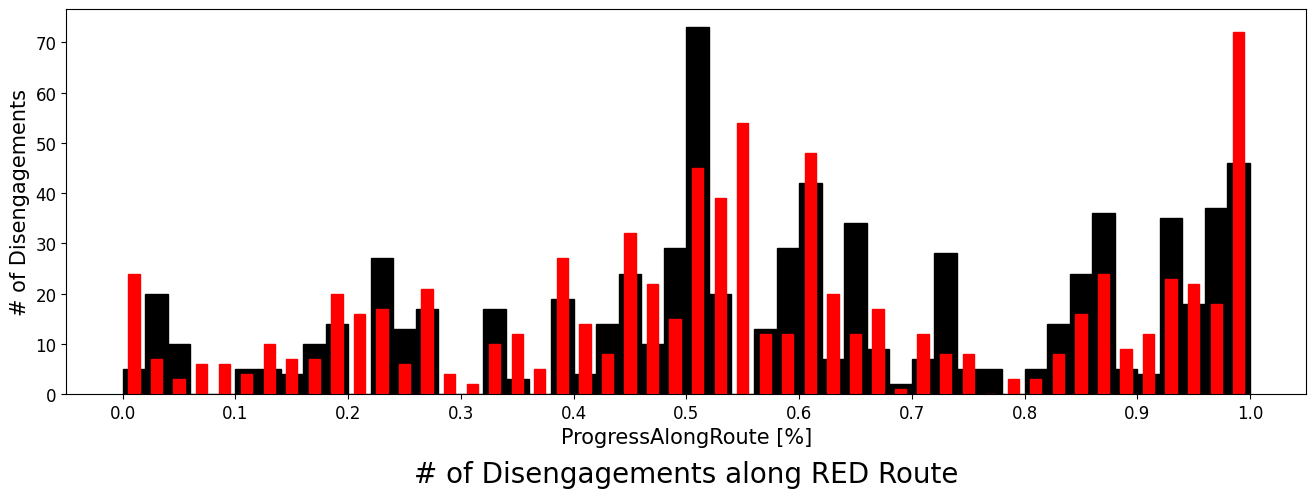

In [49]:
actual_disengagement_progress_along_route_test =  red_testing_df[ red_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'ProgressAlongRoute' ]

#

predicted_disengagement_progress_along_route_test =  red_testing_df[ red_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'ProgressAlongRoute' ]

#

plt.figure( figsize = ( 16, 5 ) )

bins = [ ( 1 / 50 ) * n for n in range( 51 ) ]

plt.hist( actual_disengagement_progress_along_route_test, bins = bins, color = 'black', edgecolor = 'black' )

plt.hist( predicted_disengagement_progress_along_route_test, bins = bins, color = 'red', edgecolor = 'red', rwidth = 0.5 )

plt.xticks( np.linspace( 0, 1, 11 ) )

plt.xticks( fontsize = 12 )

plt.yticks( fontsize = 12 )

plt.xlabel( 'ProgressAlongRoute [%]', fontsize = 15 )

plt.ylabel( '# of Disengagements', fontsize = 15 )

plt.title( '# of Disengagements along RED Route', fontsize = 20, y = -0.25 )

In [52]:
def prepare_map_settings( route_color ):

    plt.figure( figsize = ( 8, 8 ) )

    #

    if ( route_color == 'Red' ):

        minLat, maxLat = 39.3124906671225, 39.40448581121833
        
        minLon, maxLon = -82.10582075491102, -81.9788697421841

    elif ( route_color == 'Green' ):

        minLat, maxLat = 39.28843222457655, 39.33215131664078
        
        minLon, maxLon = -82.46754600607878, -82.4289058208249

    elif ( route_color == 'Blue' ):

        minLat, maxLat = 39.31899122387631, 39.38797086107572
        
        minLon, maxLon = -82.14449476722909, -82.10122278485707

    #

    expansion_coeff = 0.005

    #

    street_map = GoogleTiles( style = 'street' )

    ax = plt.axes( projection = street_map.crs )

    ax.set_extent( [ minLon - expansion_coeff , \
                     maxLon + expansion_coeff, \
                     minLat - expansion_coeff, \
                     maxLat + expansion_coeff ], \
                     ccrs.PlateCarree() )

    ax.add_image( street_map, 14 )